# FDDES Project 2026

This is the main working file of the project. Here, we review the computations done in "fdd/...". This acts as the main pipeline (imports and runs preprocessing, fd-methods, evaluation, etc).   

In [1]:
import matplotlib.pyplot as plt
import numpy as np

## Data loading and preprocessing

In [2]:
from fdd.dataloader import DataLoader
from fdd.preprocessor import StandardPreprocessor

# LOAD DATA 
loader = DataLoader("data/FaultyCase1.mat")
datasets = loader.load()

# EXPLORE & PREPROCESS DATA
set1_1 = datasets["Set1_1"]
print(set1_1.summary())

preprocessor = StandardPreprocessor(with_standardization=True, n_lags=0)
set1_1_processed = preprocessor.fit_transform(set1_1)

set1_1_processed.sensors.head()

TimeSeriesDataset(name=Set1_1, n_samples=5811, n_features=23)


,Air_Delivery_P,P_Bottom_Riser,P_Top_Riser,P_Top_Separator,P_3Phase_Separator,Diff_P_Riser,Diff_P_VC404,Air_In_Flow,Water_In_Flow,Flow_Top_Riser,...,Density_Top_Sep_Out,Density_Water_In,Temp_Top_Riser,Temp_Top_Sep_Out,Temp_Water_In,Level_3Phase_Sep,Pos_VC501,Pos_VC302,Pos_VC101,Pump_Current_PO1
0,-0.604313,-1.487589,-0.429108,-0.218923,-0.249461,-1.360272,-0.667424,-0.757619,-2.709132,-0.483505,...,0.840737,-2.300165,-2.419796,-0.490121,2.120643,-1.241061,-0.713515,-1.093246,-2.726715,-1.089215
1,-0.607351,-1.522502,-0.447710,-0.263792,-0.211532,-1.392841,-0.558436,-0.758392,-2.709109,-0.483506,...,0.840738,-2.312683,-2.426182,-0.490614,2.136148,-1.241830,-0.711193,-1.092428,-2.726627,-1.769269
2,-0.609644,-1.529798,-0.385399,-0.280807,-0.173606,-1.418974,-0.607091,-0.759097,-2.709087,-0.483506,...,0.840739,-2.325313,-2.432567,-0.491085,2.151675,-1.242599,-0.707489,-1.091609,-2.726537,-2.505997
3,-0.610230,-1.539393,-0.296115,-0.206138,-0.135685,-1.442961,-0.688833,-0.759331,-2.709064,-0.483507,...,0.840740,-2.337719,-2.438953,-0.491555,2.167185,-1.243368,-0.703783,-1.090790,-2.726448,-2.524888
4,-0.611301,-1.564904,-0.301699,-0.100873,-0.108485,-1.466948,-0.605145,-0.759432,-2.709041,-0.483507,...,0.840740,-2.350125,-2.445334,-0.492048,2.182711,-1.244136,-0.700079,-1.089971,-2.726358,-0.843639


## PCA transform

In [3]:
from fdd.pca import pca_transform

# X from preprocessing; Z is PCA-transformed X
X = set1_1_processed.sensors
Z, evr = pca_transform(X, n_components=2)

print('Original X shape:', X.shape)
print('PCA-transformed Z shape:', Z.shape)
print('Explained variance ratio:', evr.values)
print('Cumulative explained variance:', evr.cumsum().values)
print('Total explained variance:', evr.sum())
print(Z.head())

Original X shape: (5811, 23)
PCA-transformed Z shape: (5811, 2)
Explained variance ratio: [0.2915427  0.18029617]
Cumulative explained variance: [0.2915427  0.47183886]
Total explained variance: 0.4718388636340094
         Z1        Z2
0  5.282163 -1.341873
1  5.361344 -1.346572
2  5.442785 -1.342133
3  5.484963 -1.272046
4  5.325545 -1.164407


The total explained variance is only 47% meaning only 47% of the data can be explained with these two principal components. Therefore a 2D PCA is mainly used for visualization and not as a complete representation. 

Since X has been reduced down to 2 "features" in Z, that makes us able to plot them.

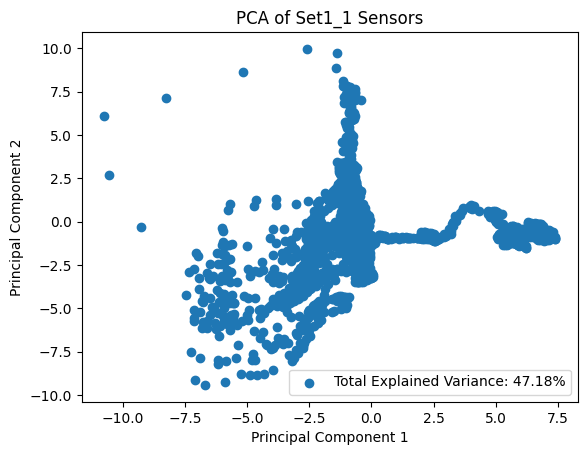

In [4]:
plt.scatter(Z["Z1"], Z["Z2"])
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
# plot the total explained variance as a legend in the plot
plt.title("PCA of Set1_1 Sensors")
plt.legend([f'Total Explained Variance: {evr.sum()*100:.2f}%'])          
plt.show()

This plot shows feature 1 and feature 2 on the x- and y-axis. 

Q and T2 statistics

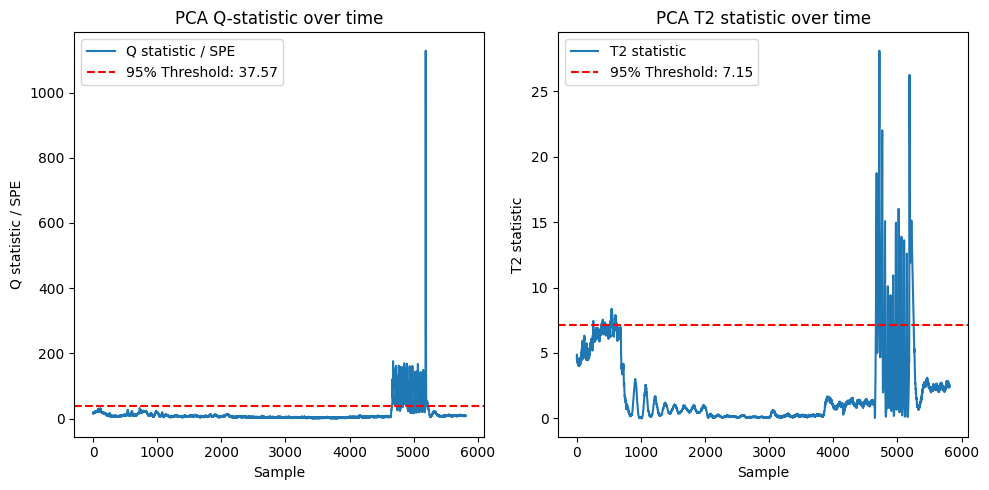

In [12]:
# Q-statistic
from fdd.statistics import q_statistic
q_values = q_statistic(X, Z)
threshold_q = np.percentile(q_values, 95)

# Hotteling's T2 statistic
from fdd.statistics import t2_statistic
t2_values = t2_statistic(Z)
threshold_t2 = np.percentile(t2_values, 95)

# Plot Q-statistic and T2 statistic over time with thresholds
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.plot(q_values, label='Q statistic / SPE')
plt.axhline(y=threshold_q, color='r', linestyle='--', label=f'95% Threshold: {threshold_q:.2f}')
plt.xlabel("Sample")
plt.ylabel("Q statistic / SPE")
plt.title("PCA Q-statistic over time")
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(t2_values, label='T2 statistic')
plt.axhline(y=threshold_t2, color='r', linestyle='--', label=f'95% Threshold: {threshold_t2:.2f}')
plt.xlabel("Sample")
plt.ylabel("T2 statistic")
plt.title("PCA T2 statistic over time")
plt.legend()
plt.tight_layout()
plt.show()

## DPCA transform

## FDA transform